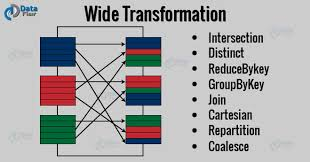

# Group by Key - groupByKey() is a wide transformation in PySpark used on Pair RDDs (RDDs with key–value pairs).

# It groups all values with the same key together into a single collection (like a list or iterator).

# Because all values for a given key must be brought together, data shuffling occurs across the cluster — making it an expensive operation.



In [1]:
from pyspark import SparkContext
sc = SparkContext("local", "groupByKey Example")

rdd = sc.parallelize([
    ('a', 1), ('b', 2), ('a', 3), ('b', 4), ('c', 5),('d',8)
])

# Group values by key
grouped = rdd.groupByKey()

# Convert grouped values (iterator) to list for readability
result = [(k, list(v)) for k, v in grouped.collect()]
print(result)

# Outpit :  [('a', [1, 3]), ('b', [2, 4]), ('c', [5])]

[('a', [1, 3]), ('b', [2, 4]), ('c', [5]), ('d', [8])]


# Reduce by key -- reduceByKey() is a wide transformation applied on Pair RDDs ((key, value) pairs).

# It aggregates the values for each key using a specified reduction function (like sum, max, min, etc.).

# Unlike groupByKey(), it performs local (map-side) aggregation before shuffling — making it much more efficient.



In [4]:
from pyspark import SparkContext
#sc = SparkContext("local", "reduceByKey Example")

rdd = sc.parallelize([
    ('a', 1), ('b', 2), ('a', 3), ('b', 4), ('c', 5),('d',8)
])

# Reduce values by key
result = rdd.reduceByKey(lambda x, y: x + y)

print(result.collect())

# Output :  [('a', 4), ('b', 6), ('c', 5)]


[('a', 4), ('b', 6), ('c', 5), ('d', 8)]


# aggregateByKey() - aggregateByKey() is a wide transformation applied on Pair RDDs ((key, value) pairs).

# It allows you to perform custom aggregations on the values of each key — with different logic for combining values within a partition and across partitions.

In [ ]:
from pyspark import SparkContext
sc = SparkContext("local", "aggregateByKey Example")

rdd = sc.parallelize([
    ('a', 1), ('b', 2), ('a', 3), ('b', 4), ('c', 5)
])

# zeroValue = 0
# seqFunc = add values within partition
# combFunc = add values from different partitions
result = rdd.aggregateByKey(0,
                            lambda x, y: x + y,   # within partition
                            lambda x, y: x + y)   # across partitions

print(result.collect())

# Output:  [('a', 4), ('b', 6), ('c', 5)]


# join() -- join() is a wide transformation that combines two Pair RDDs (RDDs of key–value pairs) based on matching keys.
# It performs an inner join by default — only keys that appear in both RDDs are included in the result.

In [5]:
from pyspark import SparkContext
#sc = SparkContext("local", "Join Example")

# Create two RDDs
rdd1 = sc.parallelize([
    ('a', 1), ('b', 2), ('c', 3),('b', 'banana')
])

rdd2 = sc.parallelize([
    ('a', 'apple'), ('b', 'banana'), ('d', 'date'),('a', 'aabc')
])

# Perform inner join
result = rdd1.join(rdd2)

print(result.collect())

# output [('a', (1, 'apple')), ('b', (2, 'banana'))]


[('b', (2, 'banana')), ('b', ('banana', 'banana')), ('a', (1, 'apple')), ('a', (1, 'aabc'))]


In [6]:
rdd1 = sc.parallelize([('a', 1), ('b', 2), ('c', 3)])
rdd2 = sc.parallelize([('a', 'apple'), ('b', 'banana'), ('d', 'date')])

# Left Outer Join
left = rdd1.leftOuterJoin(rdd2)
print(left.collect())

# output :  [('a', (1, 'apple')), ('b', (2, 'banana')), ('c', (3, None))]



[('b', (2, 'banana')), ('c', (3, None)), ('a', (1, 'apple'))]


# The distinct() transformation is used to remove duplicate elements from an RDD.

# It returns a new RDD that contains only unique records.

# Because Spark must check data across all partitions to find and eliminate duplicates, it needs to shuffle data — making distinct() a wide transformation.

In [ ]:
from pyspark import SparkContext
sc = SparkContext("local", "Distinct Example")

rdd = sc.parallelize([1, 2, 3, 2, 4, 3, 5, 1])

# Remove duplicates
distinct_rdd = rdd.distinct()

print(distinct_rdd.collect())

# output [1, 2, 3, 4, 5]



# The repartition() transformation is used to increase or decrease the number of partitions in an RDD or DataFrame by reshuffling the data across the cluster.

# Because it involves shuffling all data between partitions, repartition() is a wide transformation.

# rdd.repartition(numPartitions)

In [10]:
from pyspark import SparkContext
#sc = SparkContext("local", "Repartition Example")

rdd = sc.parallelize(range(1, 11), 2)  # 2 partitions initially
print("Initial partitions:", rdd.getNumPartitions())

#print(rdd.glom().collect())

# Increase to 4 partitions
rdd_repart = rdd.repartition(1)
print("After repartition:", rdd_repart.getNumPartitions())

# View data distribution
print(rdd_repart.glom().collect())

# output




Initial partitions: 2
After repartition: 1
[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]


# sortByKey() is a wide transformation applied on Pair RDDs ((key, value) pairs).

# It sorts the RDD based on the key values, either in ascending (default) or descending order.

# Because sorting requires comparing keys across all partitions, Spark must shuffle the data — making sortByKey() a wide transformation.

# rdd.sortByKey(ascending=True, numPartitions=None, keyfunc=lambda x: x)

In [ ]:
from pyspark import SparkContext
sc = SparkContext("local", "sortByKey Example")

rdd = sc.parallelize([
    (3, "apple"),
    (1, "banana"),
    (2, "orange"),
    (5, "grape"),
    (4, "melon")
])

# Sort in ascending order
sorted_rdd = rdd.sortByKey()
print(sorted_rdd.collect())

#output : [(1, 'banana'), (2, 'orange'), (3, 'apple'), (4, 'melon'), (5, 'grape')]


In [ ]:
sorted_desc = rdd.sortByKey(ascending=False)
print(sorted_desc.collect())

# Output :  [(5, 'grape'), (4, 'melon'), (3, 'apple'), (2, 'orange'), (1, 'banana')]

